<a href="https://colab.research.google.com/github/arifbin120/Customer-Behavior-Project-/blob/main/Customer_Shopping_Behaviour_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Getting Started with EDA


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df=pd.read_csv("/content/customer_shopping_behavior.csv")

In [100]:
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


In [101]:
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [102]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/19APpiDJxbWk01_a7_EYjA-yBLAGWny22Z_baNoOSlhU/edit#gid=0


In [103]:
 print(df.shape)
print(df.head())
print(df.info())
print(df.describe(include="all"))
print(df.isnull().sum())

(3900, 18)
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo Code 

In [104]:

# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [105]:
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


Create a column age group

In [106]:
labels =['Young ','Adult','Middle_aged','Senior']
df['age_group']=pd.qcut(df['Age'],q=4,labels=labels)

In [107]:
df[['Age','age_group']].head(10)

,Age,age_group
0,55,Middle_aged
1,19,Young
2,50,Middle_aged
3,21,Young
4,45,Middle_aged
5,46,Middle_aged
6,63,Senior
7,27,Young
8,26,Young
9,57,Middle_aged


How often a customer purchases

In [108]:
frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-weekly': 14,
    'Annualy': 365,
    'Every 3 months': 90
}

df['purchase_frequency_days'] = df['Frequency of Purchases'].map(frequency_mapping)

df[['purchase_frequency_days', 'Frequency of Purchases']].head(10)

,purchase_frequency_days,Frequency of Purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,NaN,Annually
5,7.0,Weekly
6,90.0,Quarterly
7,7.0,Weekly
8,NaN,Annually
9,90.0,Quarterly


In [109]:
# View both columns
df[['Discount Applied', 'Promo Code Used']].head(10)

# Update 'Discount Applied' based on 'Promo Code Used'
df['Discount Applied'] = df['Promo Code Used']

# Verify the result
df[['Discount Applied', 'Promo Code Used']].head(5)

,Discount Applied,Promo Code Used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [110]:
df[['Discount Applied']]=df['Promo Code Used'].all()
print(df['Discount Applied'])

0       True
1       True
2       True
3       True
4       True
        ... 
3895    True
3896    True
3897    True
3898    True
3899    True
Name: Discount Applied, Length: 3900, dtype: bool


What is the average purchase amount by category?

Category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64


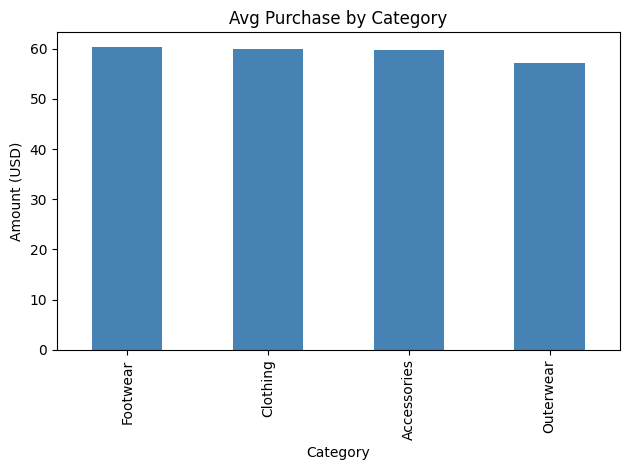

In [111]:
avg_purchase = df.groupby("Category")["Purchase Amount (USD)"].mean().sort_values(ascending=False)
print(avg_purchase)

avg_purchase.plot(kind="bar", color="steelblue", title="Avg Purchase by Category")
plt.ylabel("Amount (USD)")
plt.tight_layout()
plt.show()

Which gender spends more on average?

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


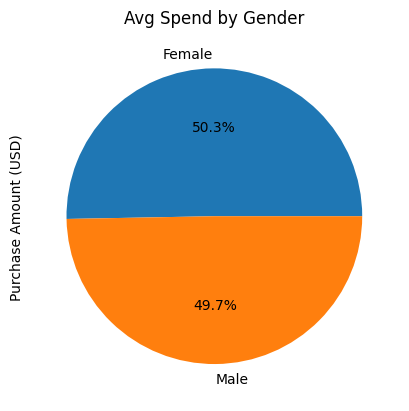

In [112]:
gender_spend = df.groupby("Gender")["Purchase Amount (USD)"].mean()
print(gender_spend)

gender_spend.plot(kind="pie", autopct="%1.1f%%", title="Avg Spend by Gender")
plt.show()

What are the top 5 most purchased items?

Item Purchased
Blouse     171
Pants      171
Jewelry    171
Shirt      169
Dress      166
Name: count, dtype: int64


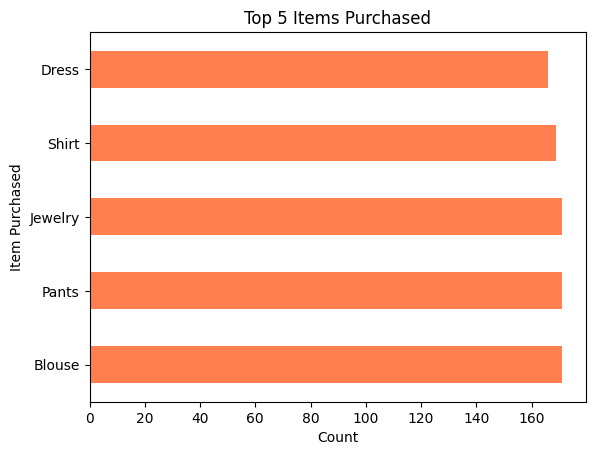

In [113]:
top_items = df["Item Purchased"].value_counts().head(5)
print(top_items)

top_items.plot(kind="barh", color="coral", title="Top 5 Items Purchased")
plt.xlabel("Count")
plt.show()

How does season affect purchase amount?

Season
Fall      61.556923
Spring    58.737738
Summer    58.405236
Winter    60.357364
Name: Purchase Amount (USD), dtype: float64


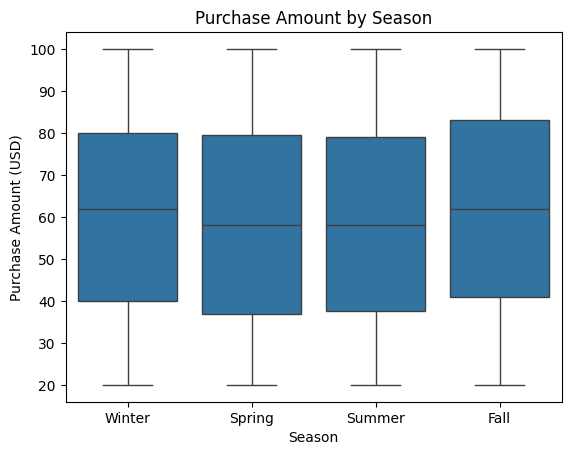

In [114]:
season_spend = df.groupby("Season")["Purchase Amount (USD)"].mean()
print(season_spend)

sns.boxplot(x="Season", y="Purchase Amount (USD)", data=df)
plt.title("Purchase Amount by Season")
plt.show()

What is the distribution of Review Ratings?

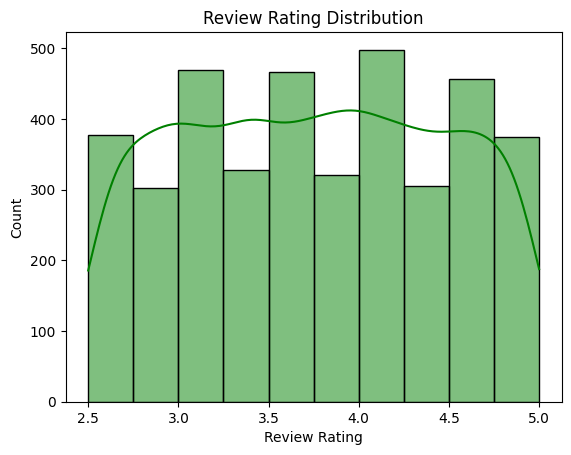

count    3900.000000
mean        3.750051
std         0.713590
min         2.500000
25%         3.100000
50%         3.800000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64


In [115]:
sns.histplot(df["Review Rating"], bins=10, kde=True, color="green")
plt.title("Review Rating Distribution")
plt.show()

print(df["Review Rating"].describe())

Which payment method is most popular?

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


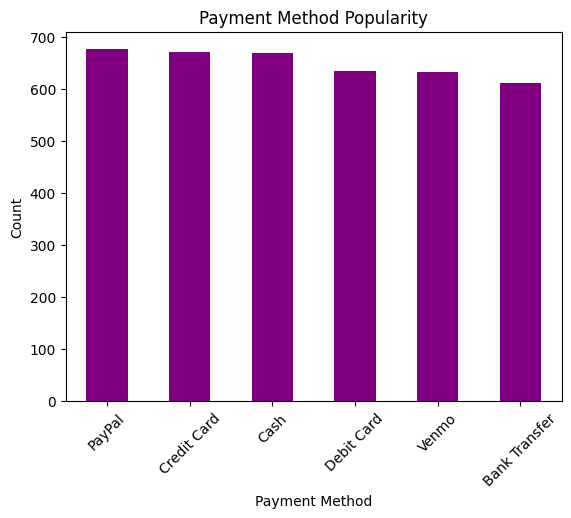

In [116]:
payment_counts = df["Payment Method"].value_counts()
print(payment_counts)

payment_counts.plot(kind="bar", color="purple", title="Payment Method Popularity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Do discount subscribers spend more than non-subscribers?

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64


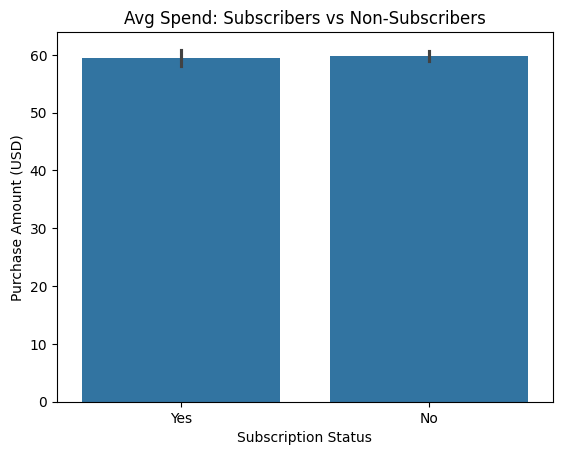

In [117]:
sub_spend = df.groupby("Subscription Status")["Purchase Amount (USD)"].mean()
print(sub_spend)
sns.barplot(x="Subscription Status", y="Purchase Amount (USD)", data=df)
plt.title("Avg Spend: Subscribers vs Non-Subscribers")
plt.show()

Which shipping type is used most by frequent buyers

Shipping Type           2-Day Shipping  Express  Free Shipping  Next Day Air  \
Frequency of Purchases                                                         
Annually                            84       96            112            81   
Bi-Weekly                           87      100             82            99   
Every 3 Months                      97       99            101           109   
Fortnightly                         89       88             79            86   
Monthly                             95       84             90           102   
Quarterly                           93       85            101            87   
Weekly                              82       94            110            84   

Shipping Type           Standard  Store Pickup  
Frequency of Purchases                          
Annually                     107            92  
Bi-Weekly                     89            90  
Every 3 Months                75           103  
Fortnightly                  107  

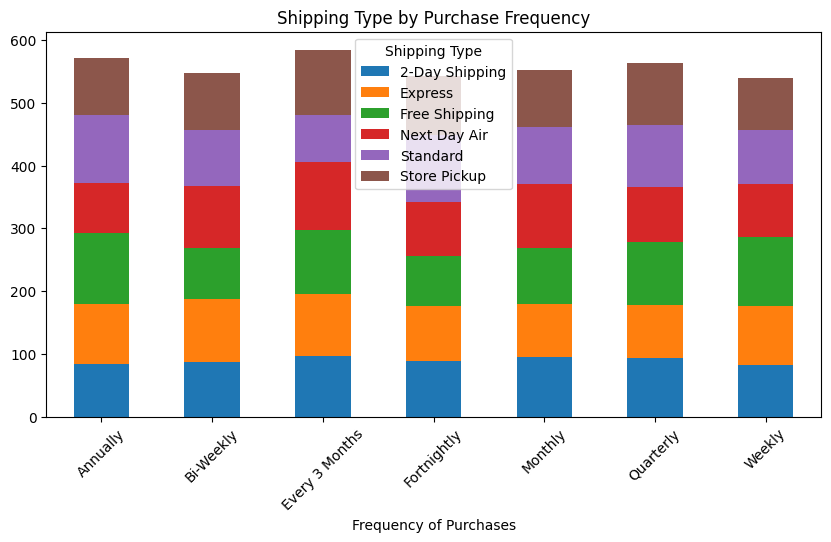

In [118]:
shipping_freq = df.groupby(["Frequency of Purchases", "Shipping Type"]).size().unstack()
print(shipping_freq)

shipping_freq.plot(kind="bar", stacked=True, figsize=(10,5))
plt.title("Shipping Type by Purchase Frequency")
plt.xticks(rotation=45)
plt.show()

What is the age group distribution of customers?

Age Group
<20      212
20-30    737
30-40    725
40-50    750
50-60    753
60+      723
Name: count, dtype: int64


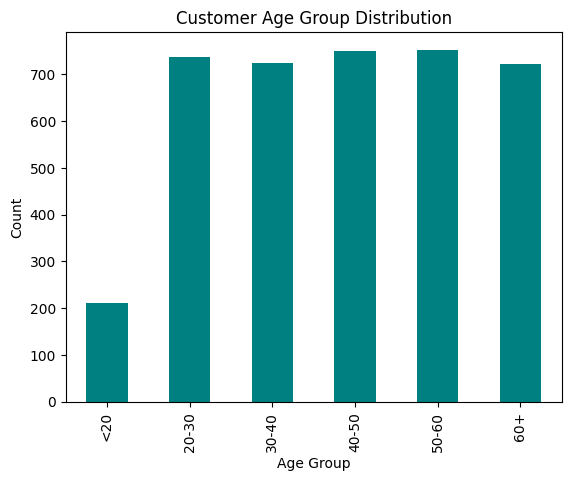

In [119]:
# Create age groups
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ["<20", "20-30", "30-40", "40-50", "50-60", "60+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_dist = df["Age Group"].value_counts().sort_index()
print(age_dist)

age_dist.plot(kind="bar", color="teal", title="Customer Age Group Distribution")
plt.ylabel("Count")
plt.show()

Now Testing og Hypothesis and Confidence Interval

*   Do Male & Female customers spend the same amount?
*   Does purchase amount differ across all 4 seasons?

*   Do subscribers spend more than non-subscribers?

*   Is Gender independent of Payment Method preference?
*   Is Discount usage related to Frequency of Purchase?

*   CI-1. 95% CI for Average Purchase Amount
*   CI-2. 95% CI — Male vs Female Spending
*   CI-3. 95% CI for Average Review Rating

In [120]:
#1.
from scipy import stats

male = df[df["Gender"] == "Male"]["Purchase Amount (USD)"]
female = df[df["Gender"] == "Female"]["Purchase Amount (USD)"]

t_stat, p_value = stats.ttest_ind(male, female)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 → There is Significant difference in spending between genders")
else:
    print("Fail to Reject H0 → There is No significant difference")

T-statistic: -0.8769
P-value: 0.3806
Fail to Reject H0 → There is No significant difference


In [121]:
#2.
spring = df[df["Season"] == "Spring"]["Purchase Amount (USD)"]
summer = df[df["Season"] == "Summer"]["Purchase Amount (USD)"]
fall   = df[df["Season"] == "Fall"]["Purchase Amount (USD)"]
winter = df[df["Season"] == "Winter"]["Purchase Amount (USD)"]

f_stat, p_value = stats.f_oneway(spring, summer, fall, winter)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 → Season significantly affects purchase amount")
else:
    print("Fail to Reject H0 → No significant difference across seasons")

F-statistic: 3.7461
P-value: 0.0106
Reject H0 → Season significantly affects purchase amount


3. Do subscribers spend more than non-subscribers?
→ One-Tailed T-Test

In [122]:
subscribed     = df[df["Subscription Status"] == "Yes"]["Purchase Amount (USD)"]
not_subscribed = df[df["Subscription Status"] == "No"]["Purchase Amount (USD)"]

t_stat, p_value = stats.ttest_ind(subscribed, not_subscribed, alternative="greater")

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print(" Reject H0 → Subscribers spend significantly MORE")
else:
    print(" Fail to Reject H0 → No significant difference")

T-statistic: -0.4368
P-value: 0.6689
 Fail to Reject H0 → No significant difference


4. Is Gender independent of Payment Method preference?
→ Chi-Square Test

In [23]:
contingency_table = pd.crosstab(df["Gender"], df["Payment Method"])
print(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi2 Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")

if p_value < 0.05:
    print("Reject H0 → Gender & Payment Method ARE related")
else:
    print(" Fail to Reject H0 → Gender & Payment Method are INDEPENDENT")

Payment Method  Bank Transfer  Cash  Credit Card  Debit Card  PayPal  Venmo
Gender                                                                     
Female                    203   212          223         181     221    208
Male                      409   458          448         455     456    426

Chi2 Statistic: 4.8776
P-value: 0.4310
Degrees of Freedom: 5
 Fail to Reject H0 → Gender & Payment Method are INDEPENDENT



5. Is Discount usage related to Frequency of Purchase?
→ Chi-Square Test

In [123]:
ct = pd.crosstab(df["Discount Applied"], df["Frequency of Purchases"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print(f"Chi2: {chi2:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print(" Discount usage IS related to purchase frequency")
else:
    print(" No relationship found")

Chi2: 0.0000, P-value: 1.0000
 No relationship found


Confidence Intervals


CI-1. 95% CI for Average Purchase Amount

In [124]:
import numpy as np

data = df["Purchase Amount (USD)"].dropna()
n = len(data)
mean = np.mean(data)
se = stats.sem(data)  # Standard Error

ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)

print(f"Mean Purchase Amount : ${mean:.2f}")
print(f"95% Confidence Interval : ${ci[0]:.2f} to ${ci[1]:.2f}")
print("We are 95% confident the true average purchase amount of ALL customers falls in this range.")

Mean Purchase Amount : $59.76
95% Confidence Interval : $59.02 to $60.51
We are 95% confident the true average purchase amount of ALL customers falls in this range.


CI-2. 95% CI — Male vs Female Spending

In [125]:
for gender in ["Male", "Female"]:
    data = df[df["Gender"] == gender]["Purchase Amount (USD)"].dropna()
    mean = np.mean(data)
    ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=stats.sem(data))
    print(f"{gender} → Mean: ${mean:.2f} | 95% CI: (${ci[0]:.2f}, ${ci[1]:.2f})")

Male → Mean: $59.54 | 95% CI: ($58.63, $60.44)
Female → Mean: $60.25 | 95% CI: ($58.95, $61.55)


CI-3. 95% CI for Average Review Rating

In [126]:
data = df["Review Rating"].dropna()
mean = np.mean(data)
ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=stats.sem(data))

print(f"Mean Rating : {mean:.2f}")
print(f"95% CI : ({ci[0]:.2f}, {ci[1]:.2f})")

Mean Rating : 3.75
95% CI : (3.73, 3.77)


SOME BUSINESS QUESTIONS

In [127]:

# Standardize column names (remove extra spaces)
df.columns = df.columns.str.strip()

print(df.columns.tolist())  # Verify column names first
print(df.shape)

['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'age_group', 'purchase_frequency_days', 'Age Group']
(3900, 21)


Q1. Total Revenue — Male vs Female

In [128]:
df1=pd.read_csv("/content/customer_shopping_behavior.csv")

In [129]:
df1


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


   TOTAL REVENUE: MALE vs FEMALE
Gender  Total Revenue
Female          75191
  Male         157890

Grand Total: $233,081.00


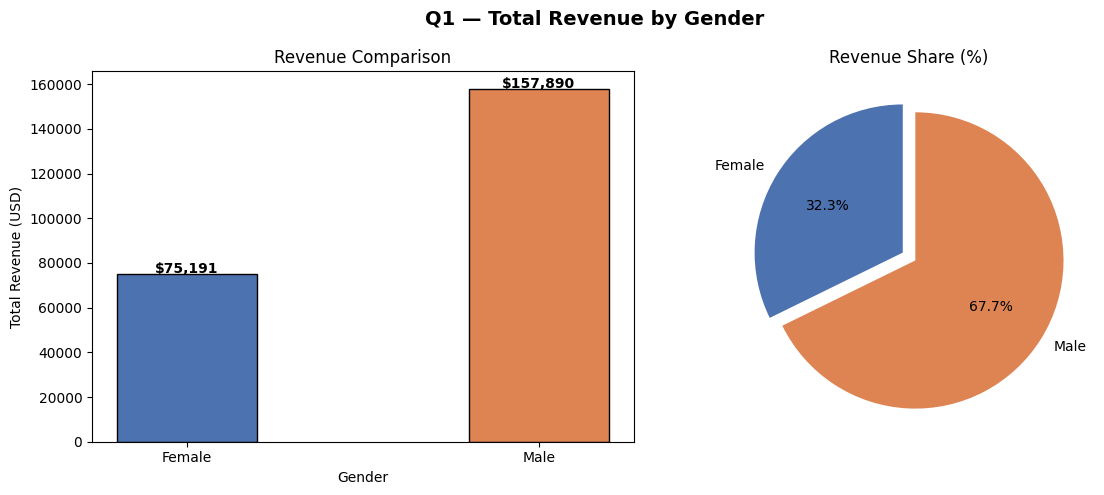

In [130]:
# ----- Calculation -----
revenue_gender = df1.groupby("Gender")["Purchase Amount (USD)"].sum().reset_index()
revenue_gender.columns = ["Gender", "Total Revenue"]
revenue_gender["Total Revenue"] = revenue_gender["Total Revenue"].round(2)

print("=" * 40)
print("   TOTAL REVENUE: MALE vs FEMALE")
print("=" * 40)

print(revenue_gender.to_string(index=False))
print(f"\nGrand Total: ${revenue_gender['Total Revenue'].sum():,.2f}")

# ----- Visualization -----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Q1 — Total Revenue by Gender", fontsize=14, fontweight="bold")

# Bar Chart
colors = ["#4C72B0", "#DD8452"]
axes[0].bar(revenue_gender["Gender"], revenue_gender["Total Revenue"],
            color=colors, edgecolor="black", width=0.4)
for i, v in enumerate(revenue_gender["Total Revenue"]):
    axes[0].text(i, v + 500, f"${v:,.0f}", ha="center", fontweight="bold")
axes[0].set_title("Revenue Comparison")
axes[0].set_ylabel("Total Revenue (USD)")
axes[0].set_xlabel("Gender")

# Pie Chart
axes[1].pie(revenue_gender["Total Revenue"],
            labels=revenue_gender["Gender"],
            autopct="%1.1f%%",
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05))
axes[1].set_title("Revenue Share (%)")

plt.tight_layout()
plt.show()

Q2. Top 5 Products with Highest Average Rating

   TOP 5 PRODUCTS BY AVERAGE RATING
Product  Avg Rating  Total Reviews
 Gloves        3.86            137
Sandals        3.84            159
  Boots        3.82            143
    Hat        3.80            153
  Skirt        3.79            157


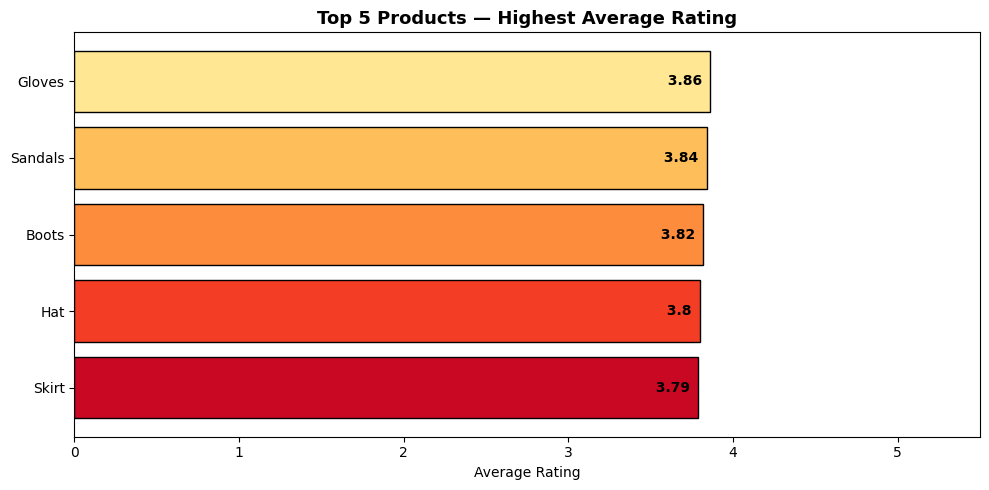

In [131]:
# ----- Calculation -----
top_rated = (df1.groupby("Item Purchased")["Review Rating"]
               .agg(["mean", "count"])
               .reset_index())
top_rated.columns = ["Product", "Avg Rating", "Total Reviews"]
top_rated["Avg Rating"] = top_rated["Avg Rating"].round(2)

# Filter products with atleast 10 reviews for reliability
top_rated = top_rated[top_rated["Total Reviews"] >= 10]
top_5_rated = top_rated.sort_values("Avg Rating", ascending=False).head(5)

print("=" * 50)
print("   TOP 5 PRODUCTS BY AVERAGE RATING")
print("=" * 50)
print(top_5_rated.to_string(index=False))

# ----- Visualization -----
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_5_rated["Product"], top_5_rated["Avg Rating"],
               color=sns.color_palette("YlOrRd", 5), edgecolor="black")

for bar, val in zip(bars, top_5_rated["Avg Rating"]):
    ax.text(bar.get_width() - 0.05, bar.get_y() + bar.get_height()/2,
            f" {val}", va="center", ha="right",
            fontweight="bold", color="black")

ax.set_title("Top 5 Products — Highest Average Rating", fontsize=13, fontweight="bold")
ax.set_xlabel("Average Rating")
ax.set_xlim(0, 5.5)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Q3. Customer Segmentation — New / Returning / Loyal

Q3. Revenue Contribution by Age Group

       REVENUE CONTRIBUTION BY AGE GROUP
Age Group  Total Revenue  Avg Purchase  Customer Count  Revenue %
      <18          43302         59.89             723       18.6
    18-25          35670         60.46             590       15.3
    26-35          39149         59.59             657       16.8
    36-45          40088         59.92             669       17.2
    46-55          40689         59.31             686       17.5
      55+          34183         59.45             575       14.7


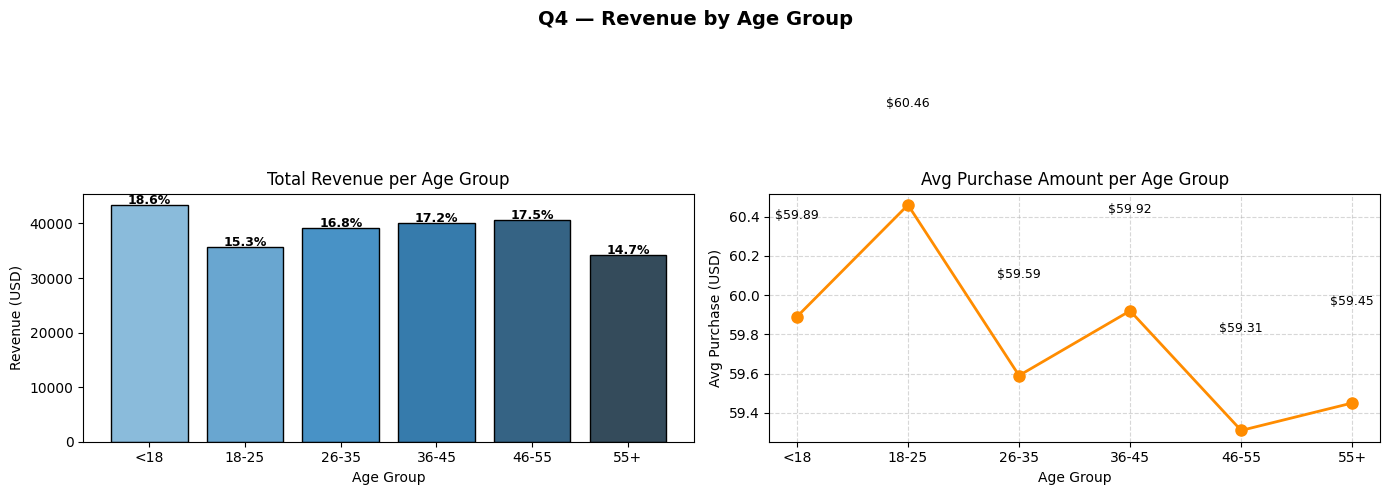

In [132]:
# ----- Create Age Groups -----
bins   = [0,  18,  25,  35,  45,  55,  100]
labels = ["<18", "18-25", "26-35", "36-45", "46-55", "55+"]
df1["Age Group"] = pd.qcut(df1["Age"], q=6, labels=labels)

age_revenue = (df1.groupby("Age Group", observed=True)["Purchase Amount (USD)"]
                 .agg(["sum", "mean", "count"])
                 .reset_index())
age_revenue.columns = ["Age Group", "Total Revenue", "Avg Purchase", "Customer Count"]
age_revenue["Revenue %"] = (age_revenue["Total Revenue"] /
                             age_revenue["Total Revenue"].sum() * 100).round(1)
age_revenue["Total Revenue"] = age_revenue["Total Revenue"].round(2)
age_revenue["Avg Purchase"]  = age_revenue["Avg Purchase"].round(2)

print("=" * 65)
print("       REVENUE CONTRIBUTION BY AGE GROUP")
print("=" * 65)
print(age_revenue.to_string(index=False))

# ----- Visualization -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q4 — Revenue by Age Group", fontsize=14, fontweight="bold")

pal = sns.color_palette("Blues_d", len(age_revenue))

# Grouped Bar — Total Revenue
bars = axes[0].bar(age_revenue["Age Group"].astype(str),
                   age_revenue["Total Revenue"],
                   color=pal, edgecolor="black")
for bar, pct in zip(bars, age_revenue["Revenue %"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f"{pct}%", ha="center", fontsize=9, fontweight="bold")
axes[0].set_title("Total Revenue per Age Group")
axes[0].set_ylabel("Revenue (USD)")
axes[0].set_xlabel("Age Group")

# Line Chart — Avg Purchase per Age Group
axes[1].plot(age_revenue["Age Group"].astype(str),
             age_revenue["Avg Purchase"],
             marker="o", color="darkorange",
             linewidth=2, markersize=8)
for i, val in enumerate(age_revenue["Avg Purchase"]):
    axes[1].text(i, val + 0.5, f"${val}", ha="center", fontsize=9)
axes[1].set_title("Avg Purchase Amount per Age Group")
axes[1].set_ylabel("Avg Purchase (USD)")
axes[1].set_xlabel("Age Group")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()